### Imports 

In [18]:
import numpy as np
import rasterio
from affine import Affine

import matplotlib.pyplot as plt
import time
import warnings

from tqdm.auto import tqdm

from skimage.filters.rank import entropy
from skimage.morphology import disk


### Gaussian Process (optional)

In [19]:
# ==========================================================
# OPTIONAL GAUSSIAN PROCESS SUPPORT
# ==========================================================

USE_GAUSSIAN_PROCESS = True #If you want to compare with GP

if USE_GAUSSIAN_PROCESS:

    from sklearn.gaussian_process import (
        GaussianProcessRegressor
    )

    from sklearn.gaussian_process.kernels import (
        RBF,
        WhiteKernel
    )

    from sklearn.exceptions import (
        ConvergenceWarning
    )

    warnings.filterwarnings(
        "ignore",
        category=ConvergenceWarning
    )

### Parameters 

Patch size and overlap decides the "adaptiveness" of the algorithm small-scale structures. Higher patch size takes into account larger structures, but results in boxiness. Overlap should be maximised with the only issue being computational cost.

In [20]:

INPUT_IMAGE = (
    r"C:\Users\Fedor\Downloads\fractal-interpl\test\sent3.tiff") # Replace with your input image path

OUTPUT_ADAPTIVE = "adaptive_output.tif" #Replace with your output path
OUTPUT_GP = "gp_output.tif"

SCALE = 10

PATCH_SIZE = 5
OVERLAP = 3

ITERATIONS = 1 # Does not have a large effect on the results, but increases runtime dramatically.

### This part defines all functions for fractal and GP interpolation

In [21]:
# ==========================================================
# FRACTAL FUNCTIONS
# ==========================================================

def d(x):

    return float(x[-1] - x[0])


def an(x, i):

    return (x[i] - x[i - 1]) / d(x)


def dn(x, i):

    return x[i - 1] / d(x)


def cn(x, y, i, sn):

    return (
        (y[i] - y[i - 1]) / d(x)
        -
        sn * ((y[-1] - y[0]) / d(x))
    )


def en(x, y, i, sn):

    return (
        (x[-1] * y[i - 1] - x[0] * y[i]) / d(x)
        -
        sn * (
            (x[-1] * y[0] - x[0] * y[-1])
            / d(x)
        )
    )


def Wn(X, U, i, sn):

    R = np.array([
        [an(U[:, 0], i), 0],
        [cn(U[:, 0], U[:, 1], i, sn), sn]
    ])

    T = np.array([
        dn(U[:, 0], i),
        en(U[:, 0], U[:, 1], i, sn)
    ])

    return R @ X + T


def G(U, sn):

    X = U.copy()

    x = list(X[:, 0])
    y = list(X[:, 1])

    M = U.shape[0]
    N = X.shape[0]

    for i in range(N):

        for j in range(1, M):

            xp, yp = Wn(X[i], U, j, sn)

            x.append(xp)
            y.append(yp)

    X = np.vstack((x, y)).T

    X = X[X[:, 0].argsort()]

    _, idx = np.unique(
        X[:, 0],
        return_index=True
    )

    return X[idx]


def FIF(U,
        sn=0.05,
        iterations=1):

    X = U.copy()

    for _ in range(iterations):

        X = G(X, sn)

    return X


# ==========================================================
# 1D FRACTAL INTERPOLATION
# ==========================================================

def fractal_interpolate_1d(signal,
                           scale=2,
                           sn=0.05,
                           iterations=1):

    n = len(signal)

    x = np.linspace(0, 1, n)

    U = np.vstack((x, signal)).T

    X = FIF(
        U,
        sn=sn,
        iterations=iterations
    )

    X = X[X[:, 0].argsort()]

    xi = np.linspace(
        0,
        1,
        n * scale
    )

    yi = np.interp(
        xi,
        X[:, 0],
        X[:, 1]
    )

    return yi


# ==========================================================
# OPTIONAL GP 1D INTERPOLATION
# ==========================================================

if USE_GAUSSIAN_PROCESS:

    def gp_interpolate_1d(signal,
                          scale=2,
                          length_scale=5.0,
                          noise=0.05):

        n = len(signal)

        x = np.arange(n).reshape(-1, 1)

        y = signal.astype(np.float32)

        kernel = (
            RBF(
                length_scale=length_scale,
                length_scale_bounds=(1e-2, 1e3)
            )
            +
            WhiteKernel(
                noise_level=noise,
                noise_level_bounds=(1e-8, 1e1)
            )
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True,
            optimizer=None
        )

        gp.fit(x, y)

        xi = np.linspace(
            0,
            n - 1,
            n * scale
        ).reshape(-1, 1)

        yi = gp.predict(xi)

        return yi


# ==========================================================
# PATCH EXTRACTION
# ==========================================================

def extract_patches(img,
                    patch_size=32,
                    overlap=8):

    h, w, c = img.shape

    step = patch_size - overlap

    patches = []
    coords = []

    for y in range(
        0,
        h - patch_size + 1,
        step
    ):

        for x in range(
            0,
            w - patch_size + 1,
            step
        ):

            patch = img[
                y:y + patch_size,
                x:x + patch_size,
                :
            ]

            patches.append(patch)

            coords.append((y, x))

    return patches, coords


# ==========================================================
# ENTROPY
# ==========================================================

def compute_patch_entropy(patch):

    gray = np.mean(
        patch,
        axis=2
    ).astype(np.uint8)

    ent = entropy(
        gray,
        disk(3)
    )

    return np.mean(ent)


def entropy_to_sn(e):

    return 0.05 + 0.32 * (e / 8.0)


# ==========================================================
# FRACTAL PATCH UPSCALING
# ==========================================================

def upscale_patch(patch,
                  scale=2,
                  sn=0.05,
                  iterations=1):

    patch = patch.astype(np.float32)

    h, w, c = patch.shape

    out_rgb = np.zeros(
        (h * scale, w * scale, c),
        dtype=np.float32
    )

    for ch in range(c):

        channel = patch[:, :, ch]

        row_up = np.zeros(
            (h, w * scale),
            dtype=np.float32
        )

        for i in range(h):

            row_up[i] = fractal_interpolate_1d(
                channel[i],
                scale,
                sn,
                iterations
            )

        out = np.zeros(
            (h * scale, w * scale),
            dtype=np.float32
        )

        for j in range(w * scale):

            out[:, j] = fractal_interpolate_1d(
                row_up[:, j],
                scale,
                sn,
                iterations
            )

        out_rgb[:, :, ch] = out

    return out_rgb


# ==========================================================
# OPTIONAL GP PATCH UPSCALING
# ==========================================================

if USE_GAUSSIAN_PROCESS:

    def gp_upscale_patch(patch,
                         scale=2,
                         length_scale=5.0,
                         noise=0.05):

        patch = patch.astype(np.float32)

        h, w, c = patch.shape

        out_rgb = np.zeros(
            (h * scale, w * scale, c),
            dtype=np.float32
        )

        for ch in range(c):

            channel = patch[:, :, ch]

            row_up = np.zeros(
                (h, w * scale),
                dtype=np.float32
            )

            for i in range(h):

                row_up[i] = gp_interpolate_1d(
                    channel[i],
                    scale,
                    length_scale,
                    noise
                )

            out = np.zeros(
                (h * scale, w * scale),
                dtype=np.float32
            )

            for j in range(w * scale):

                out[:, j] = gp_interpolate_1d(
                    row_up[:, j],
                    scale,
                    length_scale,
                    noise
                )

            out_rgb[:, :, ch] = out

        return out_rgb


# ==========================================================
# RECONSTRUCTION
# ==========================================================

def reconstruct_image(patches,
                      coords,
                      shape,
                      scale=2,
                      patch_size=32):

    h, w, c = shape

    H = h * scale
    W = w * scale

    result = np.zeros(
        (H, W, c),
        dtype=np.float32
    )

    weight = np.zeros(
        (H, W, c),
        dtype=np.float32
    )

    scaled = patch_size * scale

    for patch, (y, x) in zip(
        patches,
        coords
    ):

        y2 = y * scale
        x2 = x * scale

        result[
            y2:y2 + scaled,
            x2:x2 + scaled
        ] += patch

        weight[
            y2:y2 + scaled,
            x2:x2 + scaled
        ] += 1

    result /= np.maximum(weight, 1e-8)

    return result


# ==========================================================
# ADAPTIVE FRACTAL UPSCALER
# ==========================================================

def adaptive_upscale(img):

    patches, coords = extract_patches(
        img,
        PATCH_SIZE,
        OVERLAP
    )

    results = []
    entropy_values = []

    for patch in tqdm(
        patches,
        desc="Adaptive Fractal",
        leave=True
    ):

        ent = compute_patch_entropy(patch)

        entropy_values.append(ent)

        sn = entropy_to_sn(ent)

        up = upscale_patch(
            patch,
            SCALE,
            sn,
            ITERATIONS
        )

        results.append(up)

    final = reconstruct_image(
        results,
        coords,
        img.shape,
        SCALE,
        PATCH_SIZE
    )

    return final, entropy_values, coords


# ==========================================================
# OPTIONAL GP UPSCALER
# ==========================================================

# ==========================================================
# OPTIONAL GP WHOLE-IMAGE UPSCALER
# ==========================================================

if USE_GAUSSIAN_PROCESS:

    def gp_upscale_image(img,
                         scale=2,
                         length_scale=12.0,
                         noise=0.02):

        img = img.astype(np.float32)

        h, w, c = img.shape

        out_rgb = np.zeros(
            (h * scale, w * scale, c),
            dtype=np.float32
        )

        for ch in tqdm(
            range(c),
            desc="Gaussian Process Channels"
        ):

            channel = img[:, :, ch]

            # --------------------------------------------------
            # ROW UPSCALE
            # --------------------------------------------------

            row_up = np.zeros(
                (h, w * scale),
                dtype=np.float32
            )

            for i in tqdm(
                range(h),
                desc=f"Rows channel {ch}",
                leave=False
            ):

                row_up[i] = gp_interpolate_1d(
                    channel[i],
                    scale=scale,
                    length_scale=length_scale,
                    noise=noise
                )

            # --------------------------------------------------
            # COLUMN UPSCALE
            # --------------------------------------------------

            out = np.zeros(
                (h * scale, w * scale),
                dtype=np.float32
            )

            for j in tqdm(
                range(w * scale),
                desc=f"Cols channel {ch}",
                leave=False
            ):

                out[:, j] = gp_interpolate_1d(
                    row_up[:, j],
                    scale=scale,
                    length_scale=length_scale,
                    noise=noise
                )

            out_rgb[:, :, ch] = out

        return out_rgb


# ==========================================================
# ENTROPY MAP
# ==========================================================

def build_entropy_map(shape,
                      coords,
                      entropy_values):

    h, w, _ = shape

    m = np.zeros(
        (h, w),
        dtype=np.float32
    )

    wgt = np.zeros(
        (h, w),
        dtype=np.float32
    )

    for e, (y, x) in zip(
        entropy_values,
        coords
    ):

        m[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ] += e

        wgt[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ] += 1

    return m / np.maximum(wgt, 1e-8)

### Running the algorithm

In [22]:
# ==========================================================
# IMAGE LOADING
# ==========================================================

with rasterio.open(INPUT_IMAGE) as src:

    img = src.read()

    profile = src.profile.copy()

    transform = src.transform


# ----------------------------------------------------------
# CONVERT (bands, h, w) -> (h, w, bands)
# ----------------------------------------------------------

img = np.transpose(
    img,
    (1, 2, 0)
)


# ==========================================================
# NORMALIZE IMAGE
# ==========================================================

img = img.astype(np.float32)

img -= img.min()

img /= np.maximum(
    img.max(),
    1e-8
)

img *= 255

img = img.astype(np.uint8)

print("Image shape:", img.shape)


# ==========================================================
# RUN FRACTAL
# ==========================================================

start = time.time()

adaptive, entropy_values, coords = adaptive_upscale(img)

adaptive_time = time.time() - start

print("\nFractal time:", adaptive_time)


# ==========================================================
# OPTIONAL GP RUN
# ==========================================================

if USE_GAUSSIAN_PROCESS:

    start = time.time()

    gp_result = gp_upscale_image(img)

    gp_time = time.time() - start

    print("GP time:", gp_time)


# ==========================================================
# OUTPUT PREP
# ==========================================================

adaptive_uint8 = np.clip(
    adaptive,
    0,
    255
).astype(np.uint8)

if USE_GAUSSIAN_PROCESS:

    gp_uint8 = np.clip(
        gp_result,
        0,
        255
    ).astype(np.uint8)


# ==========================================================
# UPDATE GEOREFERENCING
# ==========================================================

new_transform = transform * Affine.scale(
    1 / SCALE,
    1 / SCALE
)

profile.update(

    driver="GTiff",

    dtype=rasterio.uint8,

    count=img.shape[2],

    height=adaptive.shape[0],

    width=adaptive.shape[1],

    transform=new_transform
)

Image shape: (271, 285, 3)


Adaptive Fractal:   0%|          | 0/18894 [00:00<?, ?it/s]

Adaptive Fractal: 100%|██████████| 18894/18894 [12:28<00:00, 25.23it/s]



Fractal time: 749.4534718990326


Gaussian Process Channels: 100%|██████████| 3/3 [00:13<00:00,  4.50s/it]

GP time: 13.512990951538086


### Saving and visualisation


GeoTIFF output saved.
GP GeoTIFF output saved.


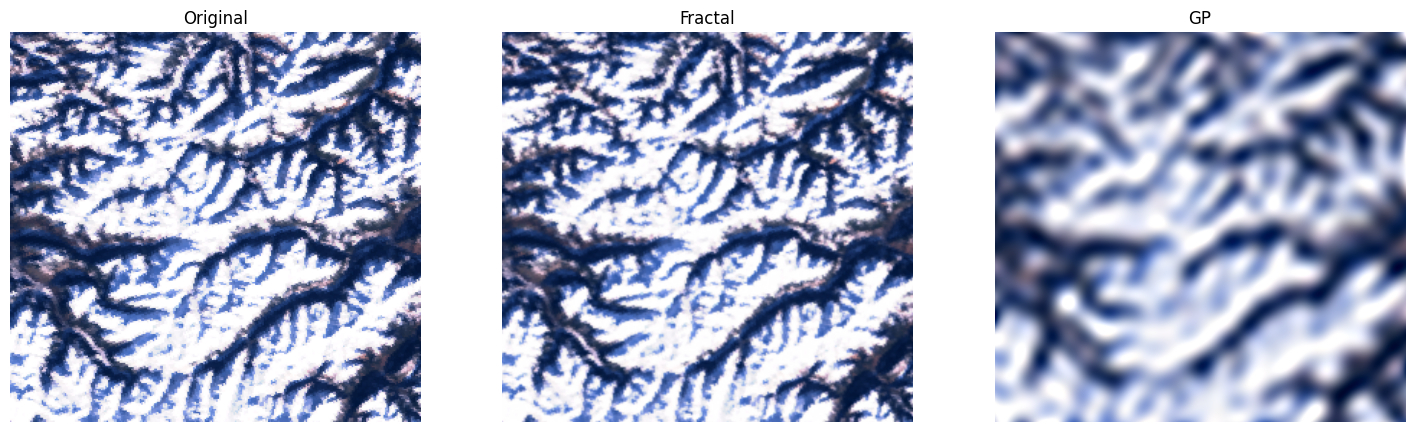

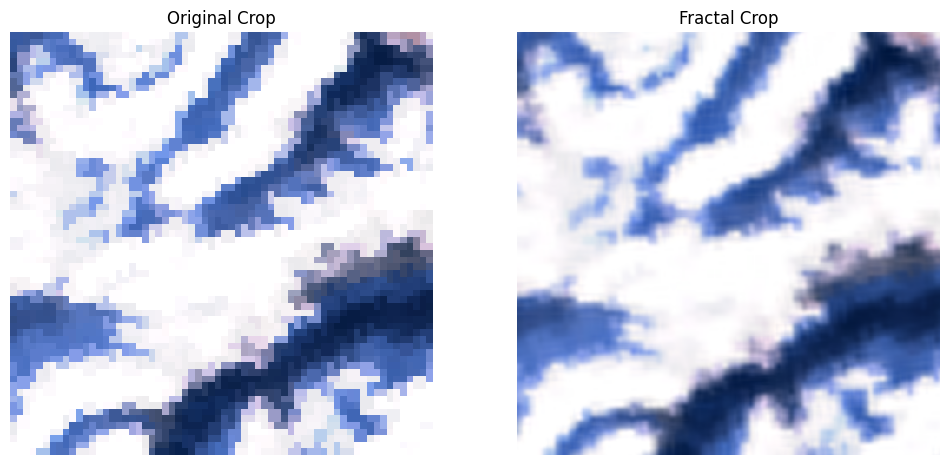

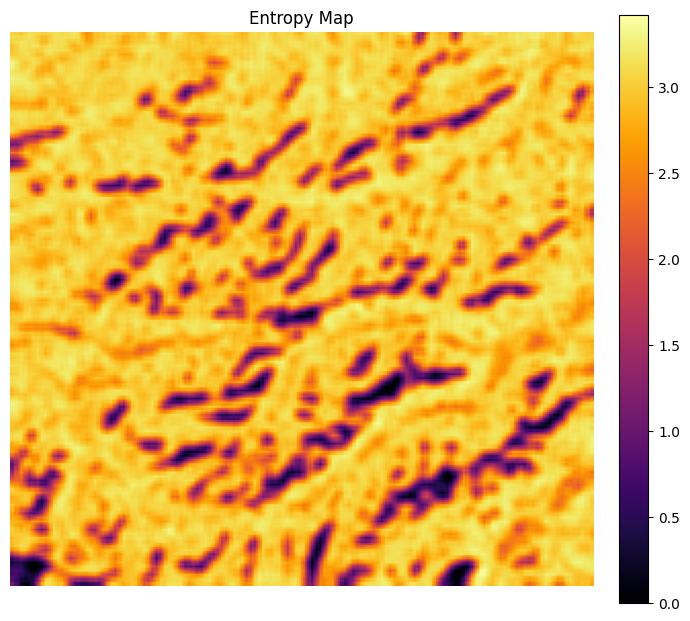


SUMMARY
Max entropy: 3.48
Mean entropy: 2.71
Fractal output shape: (2710, 2850, 3)
GP output shape: (542, 570, 3)

Done.


In [23]:
# ==========================================================
# SAVE OUTPUTS
# ==========================================================

with rasterio.open(
    OUTPUT_ADAPTIVE,
    "w",
    **profile
) as dst:

    dst.write(
        np.transpose(adaptive_uint8, (2, 0, 1))
    )

print("\nGeoTIFF output saved.")


# ==========================================================
# OPTIONAL GP SAVE
# ==========================================================

if USE_GAUSSIAN_PROCESS:

    gp_uint8 = np.clip(gp_result, 0, 255).astype(np.uint8)

    with rasterio.open(
        OUTPUT_GP,
        "w",
        **profile
    ) as dst:

        dst.write(
            np.transpose(gp_uint8, (2, 0, 1))
        )

    print("GP GeoTIFF output saved.")


# ==========================================================
# ENTROPY MAP
# ==========================================================

entropy_map = build_entropy_map(
    img.shape,
    coords,
    entropy_values
)


# ==========================================================
# CROP REGION (shared)
# ==========================================================

h, w, _ = img.shape
crop_size = 64

cy, cx = h // 2, w // 2

y0 = max(0, cy - crop_size // 2)
x0 = max(0, cx - crop_size // 2)

y0s = y0 * SCALE
x0s = x0 * SCALE
crop_scaled = crop_size * SCALE


# ==========================================================
# FIGURE 1: FULL IMAGES
# ==========================================================

n_cols = 3 if USE_GAUSSIAN_PROCESS else 2

fig1, ax1 = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))

ax1[0].imshow(img)
ax1[0].set_title("Original")
ax1[0].axis("off")

ax1[1].imshow(adaptive_uint8)
ax1[1].set_title("Fractal")
ax1[1].axis("off")

if USE_GAUSSIAN_PROCESS:
    ax1[2].imshow(gp_uint8)
    ax1[2].set_title("GP")
    ax1[2].axis("off")


# ==========================================================
# FIGURE 2: CROPS
# ==========================================================

n_cols2 = 2

fig2, ax2 = plt.subplots(1, n_cols2, figsize=(6 * n_cols2, 6))

# original crop
orig_crop = img[y0:y0 + crop_size, x0:x0 + crop_size]
ax2[0].imshow(orig_crop)
ax2[0].set_title("Original Crop")
ax2[0].axis("off")

# fractal crop
fractal_crop = adaptive_uint8[
    y0s:y0s + crop_scaled,
    x0s:x0s + crop_scaled
]

ax2[1].imshow(fractal_crop)
ax2[1].set_title("Fractal Crop")
ax2[1].axis("off")



# ==========================================================
# FIGURE 3: ENTROPY MAP ONLY
# ==========================================================

fig3, ax3 = plt.subplots(figsize=(7, 7))

im = ax3.imshow(entropy_map, cmap="inferno")
ax3.set_title("Entropy Map")
ax3.axis("off")

plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ==========================================================
# SUMMARY
# ==========================================================

print("\n======================")
print("SUMMARY")
print("======================")

print(f"Max entropy: {np.max(entropy_values):.2f}")
print(f"Mean entropy: {np.mean(entropy_values):.2f}")
print(f"Fractal output shape: {adaptive_uint8.shape}")

if USE_GAUSSIAN_PROCESS:
    print(f"GP output shape: {gp_uint8.shape}")

print("\nDone.")

### Example 1D interpolation

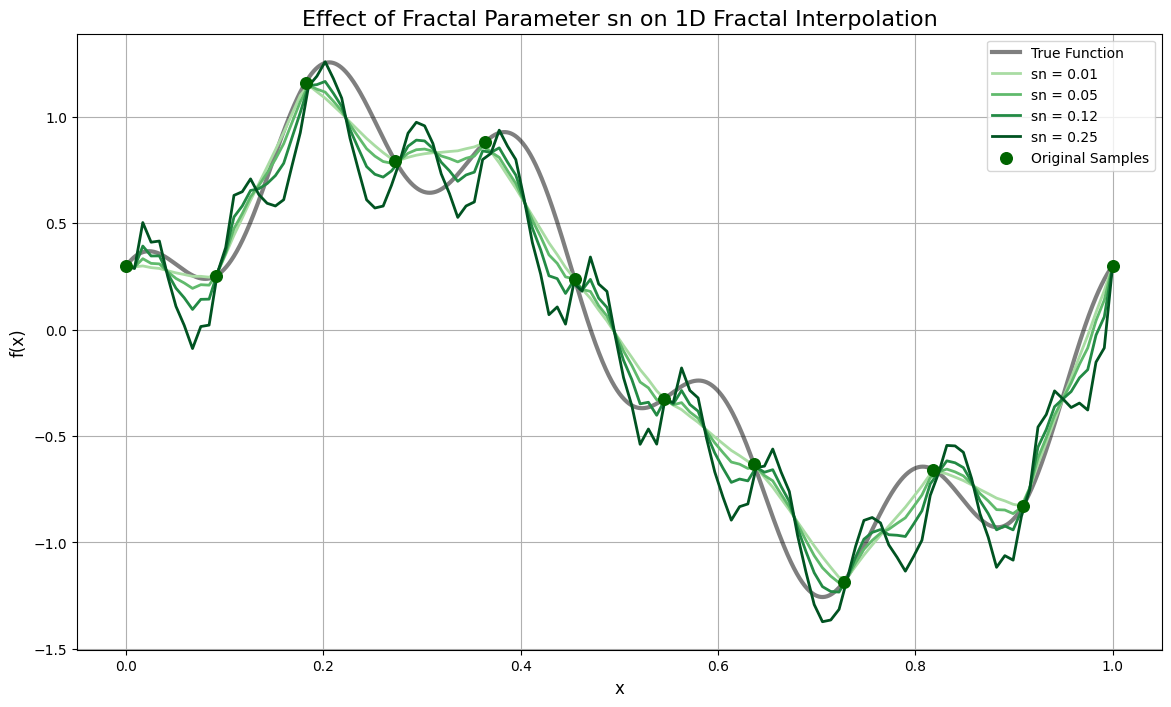

In [24]:
# ==========================================================
# 1D FRACTAL INTERPOLATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


# ==========================================================
# SAMPLE FUNCTION
# ==========================================================

def f(x):

    return (
        np.sin(2 * np.pi * x)
        + 0.3 * np.cos(10 * np.pi * x)
    )


# ==========================================================
# LOW-RES SAMPLE POINTS
# ==========================================================

x_coarse = np.linspace(0, 1, 12)
y_coarse = f(x_coarse)


# ==========================================================
# TRUE HIGH-RES FUNCTION
# ==========================================================

x_true = np.linspace(0, 1, 2000)
y_true = f(x_true)


# ==========================================================
# sn VALUES TO COMPARE
# ==========================================================

sn_values = [0.01, 0.05, 0.12, 0.25]


# ==========================================================
# COLOR MAP (dark → bright green)
# ==========================================================

cmap = cm.Greens
colors = [cmap(0.35 + 0.6 * i / (len(sn_values) - 1)) for i in range(len(sn_values))]


# ==========================================================
# DISPLAY
# ==========================================================

plt.figure(figsize=(14, 8))


# ----------------------------------------------------------
# TRUE FUNCTION
# ----------------------------------------------------------

plt.plot(
    x_true,
    y_true,
    linewidth=3,
    alpha=0.5,
    color="black",
    label="True Function"
)


# ----------------------------------------------------------
# FRACTAL INTERPOLATIONS
# ----------------------------------------------------------

for i, sn in enumerate(sn_values):

    fractal_y = fractal_interpolate_1d(
        y_coarse,
        scale=10,
        sn=sn,
        iterations=1
    )

    x_fractal = np.linspace(0, 1, len(fractal_y))

    plt.plot(
        x_fractal,
        fractal_y,
        linewidth=2,
        color=colors[i],
        label=f"sn = {sn}"
    )


# ----------------------------------------------------------
# ORIGINAL SAMPLE POINTS
# ----------------------------------------------------------

plt.scatter(
    x_coarse,
    y_coarse,
    s=70,
    zorder=5,
    color="darkgreen",
    label="Original Samples"
)


plt.title(
    "Effect of Fractal Parameter sn on 1D Fractal Interpolation",
    fontsize=16
)

plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()